# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

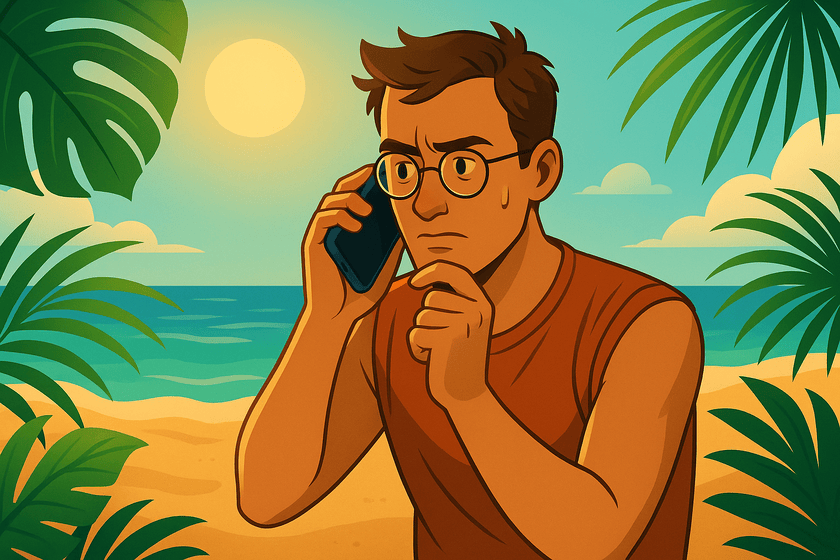

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Wczytanie danych

In [36]:
import pandas as pd
data_path = '/content/drive/MyDrive/ML/titanic.csv'
dane=pd.read_csv(data_path)
dane2 = dane.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
print(dane2.head())



   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


Predykowaną klasę oznacza zmienna Survived
Zmienna Survived oznacza predykowaną klasę

## Sprawdzenie i zmiana typów danych na właściwe


In [37]:
print(dane2.dtypes)
dane2["Survived"]=dane["Survived"].astype("category")
dane2["Pclass"]=pd.Categorical(dane2["Pclass"], categories=[1, 2, 3], ordered=True)
dane2["Sex"] = dane2["Sex"].map({"female": 0,"male": 1}).astype("category")
dane2["Embarked"]=dane2["Embarked"].map({"S": 1,"C": 2, "Q":3}).astype("category")
print(dane2.dtypes)
print(dane2.head())



Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object
Survived    category
Pclass      category
Sex         category
Age          float64
SibSp          int64
Parch          int64
Fare         float64
Embarked    category
dtype: object
  Survived Pclass Sex   Age  SibSp  Parch     Fare Embarked
0        0      3   1  22.0      1      0   7.2500      1.0
1        1      1   0  38.0      1      0  71.2833      2.0
2        1      3   0  26.0      0      0   7.9250      1.0
3        1      1   0  35.0      1      0  53.1000      1.0
4        0      3   1  35.0      0      0   8.0500      1.0


## Obsługa wartości brakujących i analiza rozkładów dla zmiennych ciągłych

In [38]:
#Patrzę ile jest wartości brakujących dla każdej kolumny
print(dane2.isna().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare         98
Embarked      2
dtype: int64


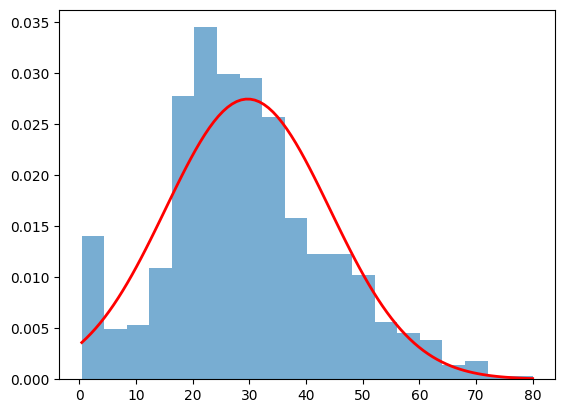

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
x=dane2['Age']
plt.hist(dane2['Age'], bins=20, density=True, alpha=0.6)

mi = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 100)
yy = norm.pdf(xx, mi, sigma)

plt.plot(xx, yy, 'r-', linewidth=2)

plt.show()

#### Rozkład zmiennej jest prawoskośny.

In [40]:
#Rozkład zmiennej Age nie jest normalny, więc zastępuję wartości brakujące medianą.
dane2['Age'] = dane2['Age'].fillna(dane2['Age'].median())

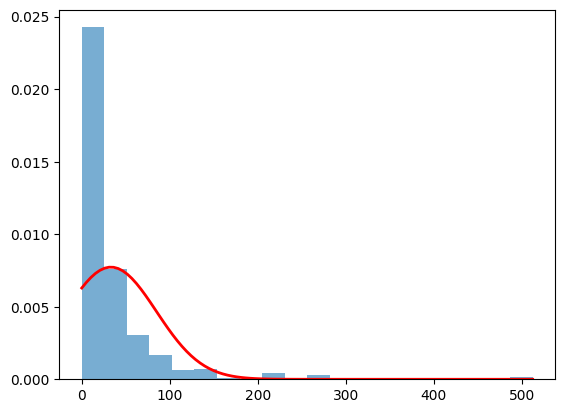

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
x=dane2['Fare']
plt.hist(dane2['Fare'], bins=20, density=True, alpha=0.6)

mi = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 100)
yy = norm.pdf(xx, mi, sigma)

plt.plot(xx, yy, 'r-', linewidth=2)

plt.show()

#### Rozkład zmiennej Fare jest prawoskośny

In [42]:
#Rozkład zmiennej Fare nie jest normalny, więc zastępuję wartości brakujące medianą.
dane2['Fare'] = dane2['Fare'].fillna(dane2['Fare'].median())

In [43]:
#W kolumnie Embarked mamy tylko 2 wartości brakujące-usuwam cały wiersz z nimi
df=dane2.dropna(subset=["Embarked"])
print(df.isna().sum())


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## Wizualizacja


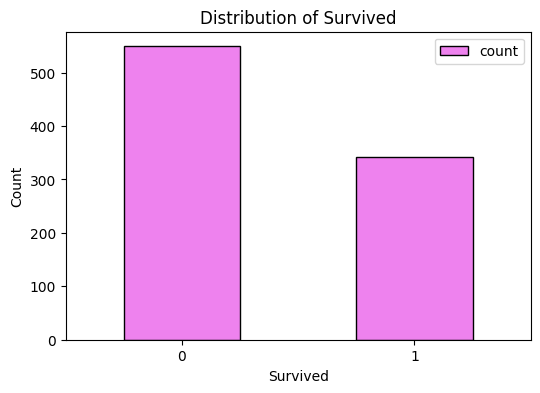

In [44]:
#rozkład zmiennej Survived
counts = dane2['Survived'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='violet', edgecolor='black')
plt.title(f'Distribution of {'Survived'}')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

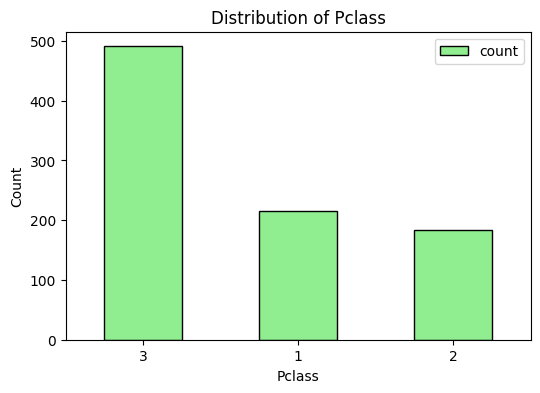

In [45]:
#rozkład zmiennej Pclass
counts = dane2['Pclass'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title(f'Distribution of {'Pclass'}')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

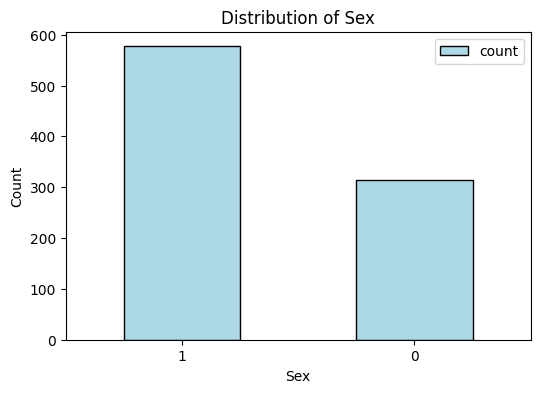

In [46]:
#rozkład zmiennej Sex
counts = dane2['Sex'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title(f'Distribution of {'Sex'}')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

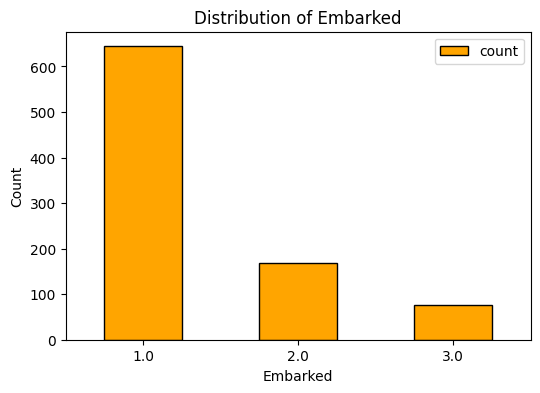

In [47]:
#rozkład zmiennej Embarked
counts = dane2['Embarked'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='orange', edgecolor='black')
plt.title(f'Distribution of {'Embarked'}')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

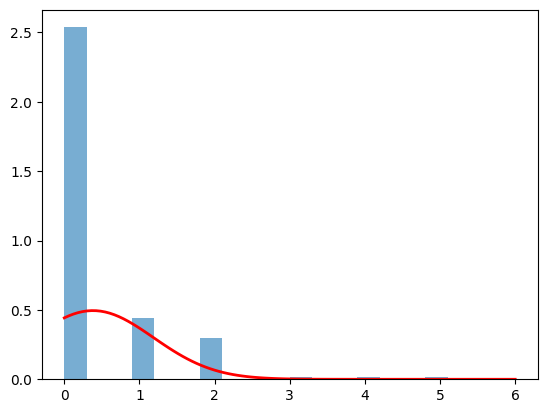

In [48]:
#Rozkład zmiennej Parch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
x=dane2['Parch']
plt.hist(dane2['Parch'], bins=20, density=True, alpha=0.6)

mi = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 100)
yy = norm.pdf(xx, mi, sigma)

plt.plot(xx, yy, 'r-', linewidth=2)

plt.show()

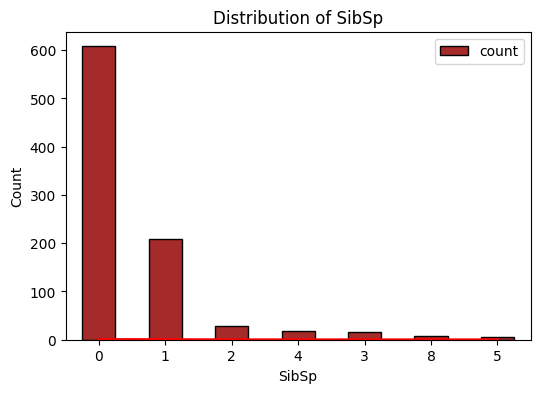

In [49]:
#rozkład zmiennej SibSp
counts = dane2['SibSp'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='brown', edgecolor='black')
plt.title(f'Distribution of {'SibSp'}')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
mi = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 100)
yy = norm.pdf(xx, mi, sigma)

plt.plot(xx, yy, 'r-', linewidth=2)
plt.show()

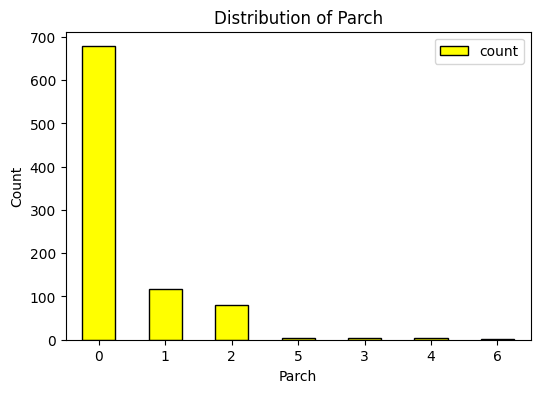

In [50]:
#rozkład zmiennej Parch
counts = dane2['Parch'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='yellow', edgecolor='black')
plt.title(f'Distribution of {'Parch'}')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

## Sprawdzenie czy występują wartości odstające za pomocą wykresów pudełkowych

In [51]:
#funkcja rysująca boxploty
import seaborn as sns
def boxplot(df, column_name):
  plt.figure(figsize=(5, 4))
  sns.boxplot(data=df[column_name], color='magenta')
  plt.title(f"Distribution of {column_name} (boxplot)")
  plt.ylabel(column_name)
  plt.tight_layout()
  plt.show()

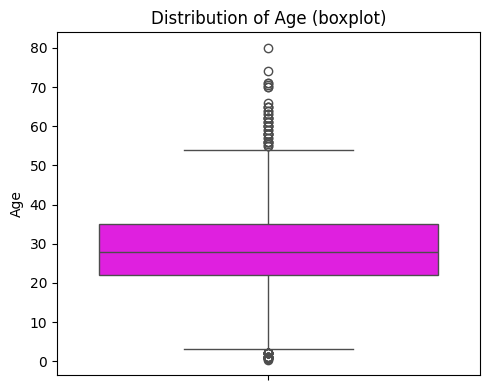

In [52]:
#Wykres pudełkowy zmiennej Age
boxplot(dane2, 'Age')

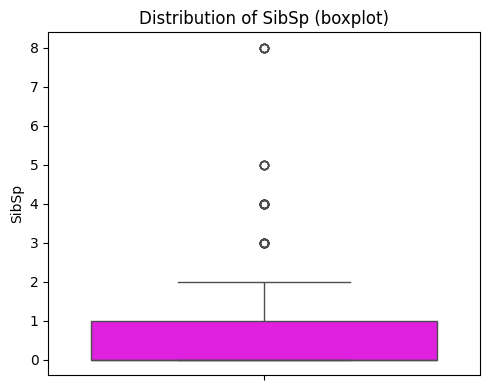

In [53]:
#Wykres pudełkowy zmiennej Sp
boxplot(dane2, 'SibSp')

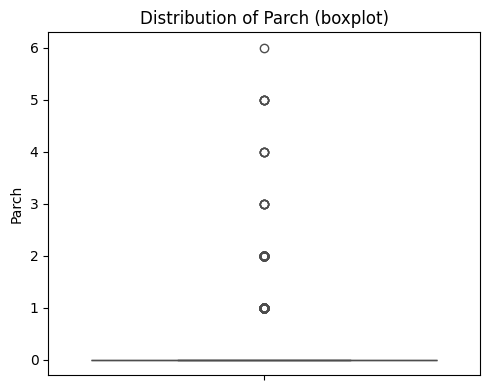

In [54]:
#Wykres pudełkowy zmiennej Parch
boxplot(dane2, 'Parch')

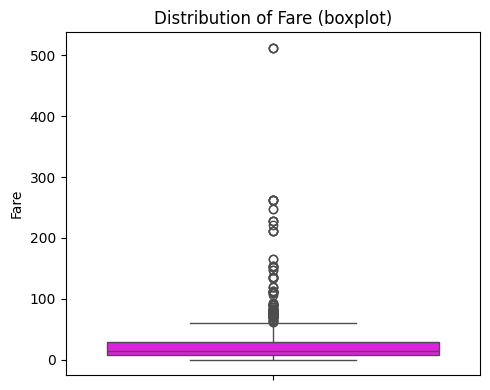

In [55]:
#Wykres pudełkowy zmiennej Fare
boxplot(dane2, 'Fare')

WNIOSEK: Wartości odstające występują we wszystkich analizowanych zmiennych tj.Age, SbSp, Parch, Fare. Co ciekawe, wykres Parch wygląda jakby były tam same wartości odstajace. Wynika to z tego, że analizowana osoba podróżowała zazwyczaj bez dzieci i rodziców (patrz:niżej).

In [56]:

sentiment_counts = dane['Parch'].value_counts()
print(sentiment_counts)

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


## Standaryzacja



Wszystkie zmienne standaryzuję za pomocą robust_scaler, ponieważ każda ma wartości odstające.

In [57]:
def robust_scaler(df, nazwa_kolumny):
  df2=df.copy()
  IQR=df[nazwa_kolumny].quantile(0.75)-df[nazwa_kolumny].quantile(0.25)
  median=df[nazwa_kolumny].median()
  if IQR==0:
    IQR=1.0
  df2[nazwa_kolumny]=(df[nazwa_kolumny]-median)/IQR
  return df2

  return (df2[nazwa_kolumny]-mean)/IQR



In [58]:
robust_scaler(dane2, 'Age')
robust_scaler(dane2,'SibSp')
robust_scaler(dane2,'Parch')
robust_scaler(dane2, 'Fare')


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,-0.344009,1.0
1,1,1,0,38.0,1,0,2.694344,2.0
2,1,3,0,26.0,0,0,-0.311981,1.0
3,1,1,0,35.0,1,0,1.831554,1.0
4,0,3,1,35.0,0,0,-0.306050,1.0
...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,-0.071174,1.0
887,1,1,0,19.0,0,0,0.735469,1.0
888,0,3,0,28.0,1,2,0.424674,1.0
889,1,1,1,26.0,0,0,0.735469,2.0


## Dodanie dwóch kolumn

In [59]:
#dodanie kolumny FCount będącą sumą wszystkich członków rodziny na pokładzie
dane2['FCount']=(dane2['SibSp']+dane2['Parch']).astype(int)

In [60]:
#dodanie kolumny SCher-zwraca 1 jeśli pasażer wsiadł w Cherbourg i przeżył, w przeciwnym wypadku 0
dane2["SChr"] = ((dane2["Survived"] == 1) & (dane2["Embarked"] == 1)).astype(int).astype("category")

## Korelacja

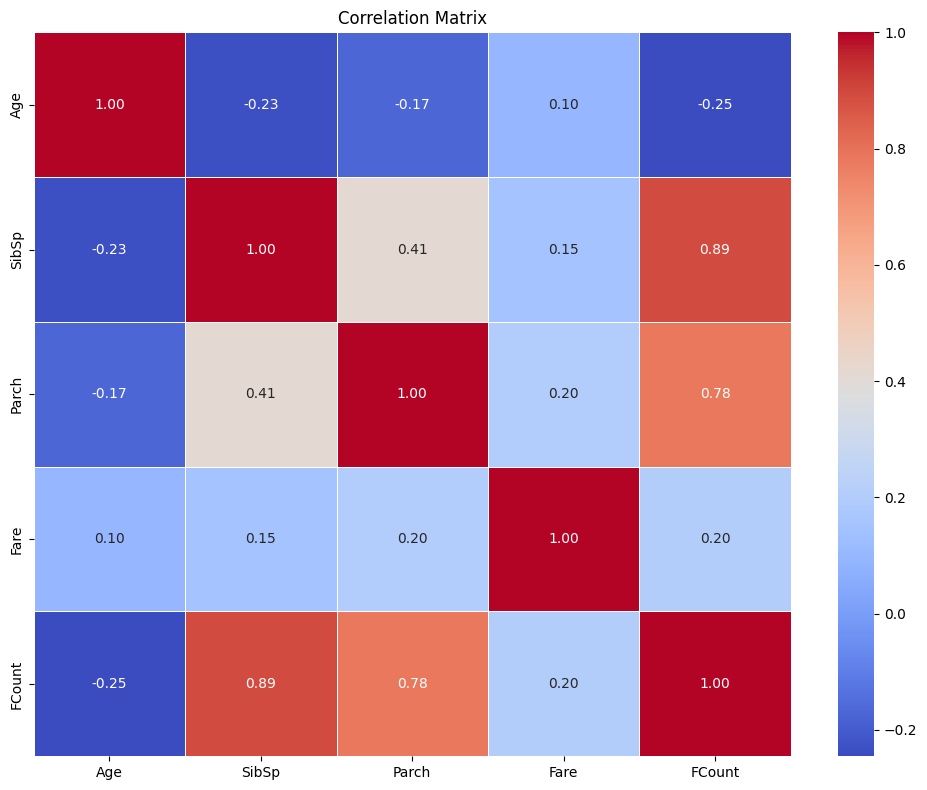

In [61]:

import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_matrix(df):
  corr = df.corr(numeric_only=True)
  plt.figure(figsize=(10, 8))
  sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
  plt.title('Correlation Matrix')
  plt.tight_layout()
  plt.show()
plot_correlation_matrix(dane2)

Największa korelacja jest między zmiennymi SibSP a Parch.

<Axes: xlabel='SibSp', ylabel='Parch'>

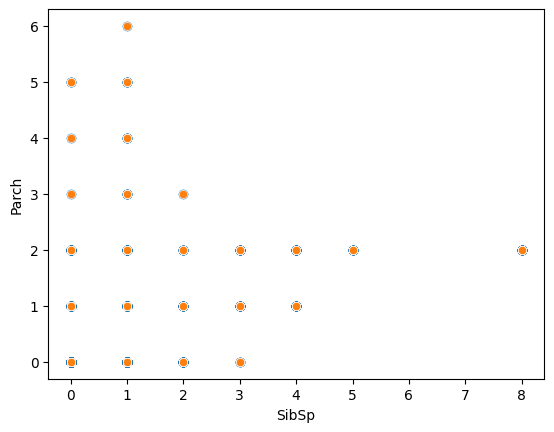

In [62]:
plt.scatter(df['SibSp'], df['Parch'])
sns.scatterplot(x='SibSp', y='Parch', data=df)

Myślę, że wizualizacje rozkładów dyskretnych nie są potrzebne w analizie. Ważniejsze jest znalezienie zależności między zmiennymi oraz wykonanie odpowiedniej standaryzacji na podstawie boxplotów i obsługa wartości brakującyc.